# Testing Signal Region Cuts
This code is for testing and plotting certain signal region (SR) cuts for the XXZX analysis.

## 1. HM 2022 SR cuts
The following cuts are taken from the 2022 High Mass (HM) analysis paper ([arXiv](https://arxiv.org/pdf/2110.13673))

In [23]:
import numpy as np
import matplotlib.pyplot as plt

Define `tailGauss` function, which consists of half of a Gaussian with an exponential tail after a certain maximum `x`.

In [24]:
def tailGauss(x, h, X, sigma, B1, B2, T):
    arg = x - X
    result = B1 + B2 * arg

    gauss = np.exp(-(arg**2) / (2.0 * sigma**2))
    tail  = np.exp(T * (2.0 * arg + T) / (2.0 * sigma**2))

    return result + np.where(x > X - T, h * gauss, h * tail)

Define `modulateSR()` function, which utilises `tailGauss()` to create a function for modulate the SR according to the mass of the leading dilepton pair, `m12`.

In [25]:
def modulateSR(m12, pars):
    h, X, sigma, B1, B2, T = pars

    # dense sampling to find xmax
    xscan = np.linspace(0.0, 200.0, 5000)
    Fscan = tailGauss(xscan, h, X, sigma, B1, B2, T)
    xmax = xscan[np.argmax(Fscan)]

    F10 = tailGauss(10.0, h, X, sigma, B1, B2, T)
    Fx  = tailGauss(xmax, h, X, sigma, B1, B2, T)

    Fm12 = tailGauss(m12, h, X, sigma, B1, B2, T)

    f = 1.0 - (Fm12 - F10) / (Fx - F10)
    f[m12 > xmax] = 0.0

    return f

Calculate and plot the SR

In [72]:
# Parameters
pars = (
    3.73,    # h
    51.6,    # X
    16.6,    # sigma
    -2.62,    # B1
    -0.0266,  # B2
    6.39     # T
)

# m12 range
m12_min = 5.0
m12_max = 100.0
m12 = np.linspace(m12_min, m12_max, 500)

In [73]:
# Compute modulation
fval = modulateSR(m12, pars)

# Boundary: m34 = m12 * (0.85 - 0.1125 * f(m12))
m34_boundary = m12 * (0.85 - 0.1125 * fval)

# Upper boundary: m34 = m12
m34_diag = m12

Plot the signal region

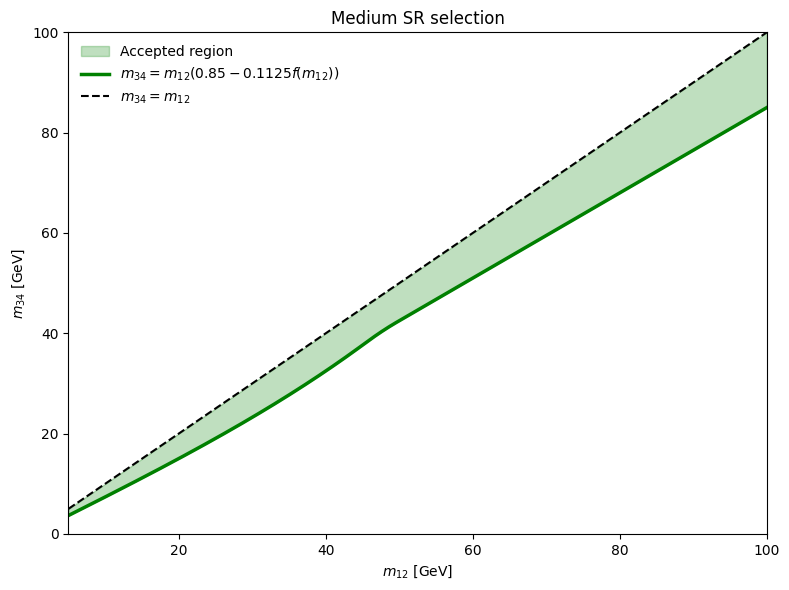


Medium SR plot saved as mediumSR_boundary.pdf
Condition:
m34 / m12 > 0.85 - 0.1125 * f(m12)
AND m34 <= m12


In [74]:
plt.figure(figsize=(8, 6))

# Shaded accepted region
plt.fill_between(m12, m34_boundary, m34_diag, color="green", alpha=0.25, label="Accepted region")
# Boundary curve
plt.plot(m12, m34_boundary, color="green", linewidth=2.5, label=r"$m_{34} = m_{12}(0.85 - 0.1125 f(m_{12}))$")
# Diagonal m34 = m12
plt.plot(m12, m34_diag, linestyle="--", color="black", label=r"$m_{34} = m_{12}$")

plt.xlim(m12_min, m12_max)
plt.ylim(0.0, m12_max)

plt.xlabel(r"$m_{12}$ [GeV]")
plt.ylabel(r"$m_{34}$ [GeV]")
plt.title("Medium SR selection")
plt.legend(frameon=False)
plt.tight_layout()

# plt.savefig("mediumSR_boundary.pdf")
plt.show()

print("\nMedium SR plot saved as mediumSR_boundary.pdf")
print("Condition:")
print("m34 / m12 > 0.85 - 0.1125 * f(m12)")
print("AND m34 <= m12")

Find the width of the accepted region

In [75]:
# Create a function that takes in a mass array and returns the corresponding m34 boundary value
def mediumSR_boundary(masses, params):
    fval = modulateSR(masses, params)
    return masses * (0.85 - 0.1125 * fval)

In [76]:
# Test mediumSR_boundary function
test_m12_values = np.array([5.0, 12.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0])
test_m12_value = np.array([30.0])
print("\nTesting mediumSR_boundary function:")
# for m12 in test_m12_values:
boundary = mediumSR_boundary(test_m12_values, pars)
boundary
# print(f"m12 = {m12:.1f} GeV -> m34 boundary = {boundary:.2f} GeV")


Testing mediumSR_boundary function:


array([ 3.67010777,  8.87349423, 15.01853379, 23.2451422 , 32.47881909,
       42.5       , 51.        , 59.5       ])

In [77]:
def width_mediumSR(masses, params):
    upper_vals = masses  # m34 <= m12
    lower_vals = mediumSR_boundary(masses, params)
    return upper_vals - lower_vals

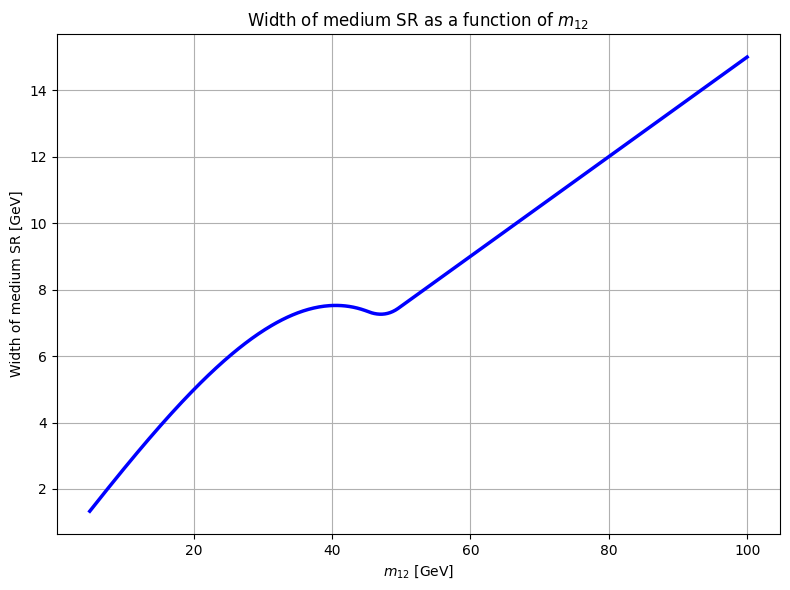

In [78]:
# Plot the width of the medium SR as a function of m12
m12_range = np.linspace(5.0, 100.0, 500)
widths = width_mediumSR(m12_range, pars)
plt.figure(figsize=(8, 6))
plt.plot(m12_range, widths, color="blue", linewidth=2.5)
plt.xlabel(r"$m_{12}$ [GeV]")
plt.ylabel(r"Width of medium SR [GeV]")
plt.title("Width of medium SR as a function of $m_{12}$")
plt.grid()
plt.tight_layout()
# plt.savefig("mediumSR_width.pdf")
plt.show()

In [79]:
def width_fraction(masses, params):
    width = width_mediumSR(masses, params)
    return width / masses

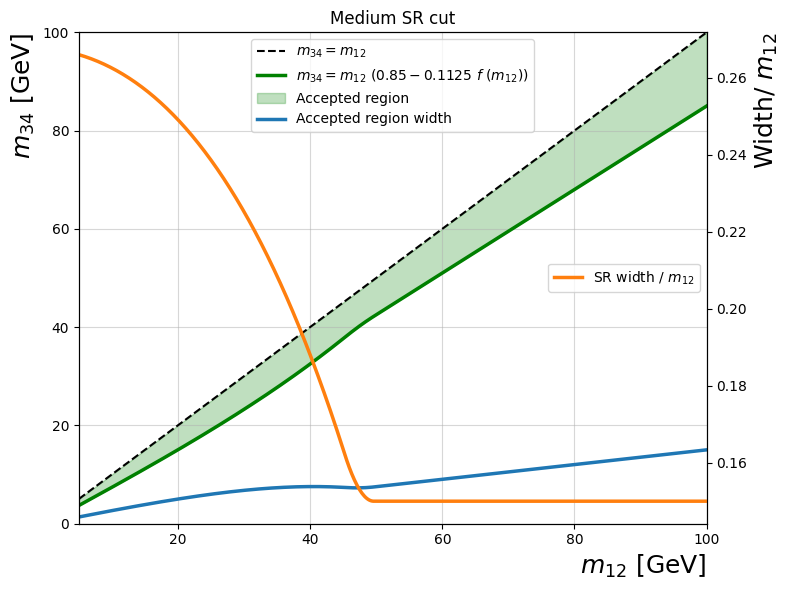

In [91]:
# Plot width of medium SR as a function of m12 on one axis, and width fraction on another axis
width_frac = width_fraction(m12_range, pars)
fig, ax1 = plt.subplots(figsize=(8, 6))
ax_label_size = 18

# Left y-axis
color1 = "tab:blue"
ax1.plot(m12, m34_diag, linestyle="--", color="black", label=r"$m_{34} = m_{12}$") # Diagonal m34 = m12
ax1.plot(m12, m34_boundary, color="green", linewidth=2.5, label=r"$m_{34} = m_{12}~(0.85 - 0.1125~f~(m_{12}))$") # Boundary curve
ax1.fill_between(m12, m34_boundary, m34_diag, color="green", alpha=0.25, label="Accepted region") # Shaded accepted region
ax1.plot(m12_range, widths, color=color1, linewidth=2.5, label="Accepted region width") # Width of medium SR

ax1.set_xlabel(r"$m_{12}$ [GeV]", fontsize=ax_label_size, loc='right')
ax1.set_ylabel(r"$m_{34}$ [GeV]", color='black', fontsize=ax_label_size, loc='top')
ax1.tick_params(axis="y", labelcolor='black')
ax1.legend(loc="upper center", frameon=True)
ax1.grid(alpha=0.5)
plt.xlim(5, 100)
plt.ylim(0.0, 100)

# Right y-axis
color2 = "tab:orange"
ax2 = ax1.twinx()
ax2.plot(m12_range, width_frac, color=color2, linewidth=2.5)
ax2.set_ylabel("Width/ $m_{12}$", color='black', fontsize=ax_label_size, loc='top')
ax2.tick_params(axis="y", labelcolor='black')
ax2.legend(["SR width / $m_{12}$"], loc="center right")

plt.title("Medium SR cut")
fig.tight_layout()
# plt.savefig("mediumSR_width_fraction.pdf")
plt.show()